## Need to add learning objectives here

# Module 5: Deep Learning Models for Cybersecurity

## Introduction to Deep Learning in Security

As cyber threats become increasingly sophisticated, traditional signature-based detection and standard machine learning techniques often struggle to keep pace. This is where **Deep Learning (DL)** steps in. Deep Learning, a subset of machine learning inspired by the structure and function of the human brain (artificial neural networks), excels at finding hidden patterns in massive, complex, and unstructured datasets.

### Why Deep Learning?

* **Feature Extraction:** Unlike traditional ML, which requires painstaking manual feature engineering, DL models can automatically learn and extract the most relevant features directly from raw data (e.g., raw network packets, binary files, or system logs).
* **Handling Complexity:** DL models thrive on high-dimensional data, making them perfect for analyzing complex network traffic patterns or analyzing the chaotic behavior of modern malware.
* **Adaptability:** Deep neural networks can generalize better to unseen, zero-day attacks by understanding underlying malicious behaviors rather than just matching known signatures.

### Key Examples of Deep Learning in Cybersecurity

1. **Advanced Malware Detection:** Deep neural networks (like Convolutional Neural Networks, or CNNs) can treat compiled binaries almost like images, scanning the raw bytes to detect malicious patterns without ever executing the code or relying on known hash signatures.
2. **Network Intrusion Detection Systems (NIDS):** Recurrent Neural Networks (RNNs) and Long Short-Term Memory (LSTM) networks are incredibly effective at analyzing time-series data. They can monitor network traffic over time to identify subtle, anomalous sequences that indicate a stealthy intrusion or Advanced Persistent Threat (APT).
3. **Phishing and Malicious URL Detection:** Natural Language Processing (NLP) models powered by deep learning can analyze the structure, semantics, and context of emails and URLs to spot incredibly convincing phishing attempts that trick standard spam filters.
4. **User and Entity Behavior Analytics (UEBA):** Autoencoders can learn the 'normal' baseline behavior for every user on a network. If an attacker compromises an account and starts acting unusually (e.g., accessing databases they normally don't touch), the deep learning model flags the anomaly immediately.

### Deep Learning in Action: Fraud Detection

In the previous module, you likely explored unsupervised learning methods (like Isolation Forest or K-Means) to detect anomalies in this credit card dataset. While those methods are great when you don't have labeled data, Deep Learning via an **Autoencoder** can often achieve much higher accuracy by learning complex representations of normal data and flagging deviations.

Here, we will build an **Autoencoder** using TensorFlow and Keras to detect fraudulent transactions based on reconstruction error. We will:
1. Preprocess and scale the data.
2. Build an Autoencoder model.
3. Train the model and evaluate its performance.

## **Important:**
* Enable T4 GPU: Down arrow in top right corner -> Change runtime type -> Select: T4 GPU -> Save.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# The URL to the zipped CSV file
url = "https://github.com/abramweigant/AI-Cyber-Intro-Cert/raw/refs/heads/main/creditcard.csv.zip"

# Load the dataset directly from the ZIP file
print(f"Downloading and loading data from: {url}...")
df = pd.read_csv(url, compression='zip')

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape} (rows, columns)")

# Display the first 5 rows
display(df.head())

Dataset loaded successfully!
Dataset shape: (284807, 31) (rows, columns)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
import numpy as np

# The 'Class' column is our label (0 = Normal, 1 = Fraud)
X = df.drop('Class', axis=1)
y = df['Class']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Suppress SettingWithCopyWarning for cleaner output
warnings.filterwarnings('ignore')

# Create copies so we don't alter the original split data directly
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Initialize the scaler
scaler = StandardScaler()

# The only columns that need scaling
cols_to_scale = ['Time', 'Amount']

# Fit the scaler ONLY on the training data, then transform both train and test
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("Scaling complete!")
print(f"Original training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
display(X_train_scaled.head())

Scaling complete!
Original training data shape: (227845, 30)
Testing data shape: (56962, 30)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
265518,1.411588,1.946747,-0.752526,-1.355130,-0.661630,1.502822,4.024933,-1.479661,1.139880,1.406819,...,-0.134435,0.076197,0.297537,0.307915,0.690980,-0.350316,-0.388907,0.077641,-0.032248,-0.322494
180305,0.623141,2.035149,-0.048880,-3.058693,0.247945,2.943487,3.298697,-0.002192,0.674782,0.045826,...,-0.227279,0.038628,0.228197,0.035542,0.707090,0.512885,-0.471198,0.002520,-0.069002,-0.339764
42664,-1.130680,-0.991920,0.603193,0.711976,-0.992425,-0.825838,1.956261,-2.212603,-5.037523,0.000772,...,1.280856,-2.798352,0.109526,-0.436530,-0.932803,0.826684,0.913773,0.038049,0.185340,0.346693
198723,0.794699,2.285718,-1.500239,-0.747565,-1.668119,-1.394143,-0.350339,-1.427984,0.010010,-1.118447,...,-0.490642,-0.139670,0.077013,0.208310,-0.538236,-0.278032,-0.162068,0.018045,-0.063005,-0.327360
82325,-0.748102,-0.448747,-1.011440,0.115903,-3.454854,0.715771,-0.147490,0.504347,-0.113817,-0.044782,...,-0.275297,-0.243245,-0.173298,-0.006692,-1.362383,-0.292234,-0.144622,-0.032580,-0.064194,-0.008281


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout

input_dim = X_train_scaled.shape[1]

# Build an Autoencoder Neural Network
input_layer = Input(shape=(input_dim,))

# Encoder
encoder = Dense(32, activation='relu')(input_layer)
encoder = Dropout(0.2)(encoder)
encoder = Dense(16, activation='relu')(encoder)

# Decoder
decoder = Dense(16, activation='relu')(encoder)
decoder = Dropout(0.2)(decoder)
decoder = Dense(32, activation='relu')(decoder)
output_layer = Dense(input_dim, activation='linear')(decoder)

# Combine into an Autoencoder model
model = Model(inputs=input_layer, outputs=output_layer)

# Compile the model
# We use Mean Squared Error (MSE) to measure reconstruction loss
model.compile(optimizer='adam', loss='mse', metrics=['accuracy'])

# Display the model architecture
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 30)             │           990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,326 (12.99 KB)

 Trainable params: 3,326 (12.99 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the Autoencoder
# CRITICAL FIX: We must train the autoencoder to reconstruct ONLY normal data.
# If we train it on the resampled data (50% fraud), it learns to reconstruct fraud too!
X_train_normal = X_train_scaled[y_train == 0]

print("Training the Autoencoder model on NORMAL transactions only...")
history = model.fit(
    X_train_normal,
    X_train_normal, # The target is the input itself
    epochs=10,
    batch_size=2048,
    validation_split=0.2,
    verbose=1
)
print("Training complete!")

Training the Autoencoder model on NORMAL transactions only...
Epoch 1/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.0585 - loss: 1.0345 - val_accuracy: 0.1495 - val_loss: 0.9080
Epoch 2/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2012 - loss: 0.8487 - val_accuracy: 0.3698 - val_loss: 0.6965
Epoch 3/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3634 - loss: 0.7220 - val_accuracy: 0.4640 - val_loss: 0.5733
Epoch 4/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4219 - loss: 0.6425 - val_accuracy: 0.5125 - val_loss: 0.5048
Epoch 5/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4610 - loss: 0.5969 - val_accuracy: 0.5661 - val_loss: 0.4602
Epoch 6/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4873 - loss: 0.5673 - val_accuracy: 0.5835 - val_loss: 0.4323
Epoch 7/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4962 - loss: 0.5484 - val_accuracy: 0.5942 - val_loss: 0.4168
Epoch 8/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
Using an anomaly threshold of: 0.8102
Confusion Matrix:
[[54101  2763]
 [   12    86]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97     56864
       Fraud       0.03      0.88      0.06        98

    accuracy                           0.95     56962
   macro avg       0.51      0.91      0.52     56962
weighted avg       1.00      0.95      0.97     56962



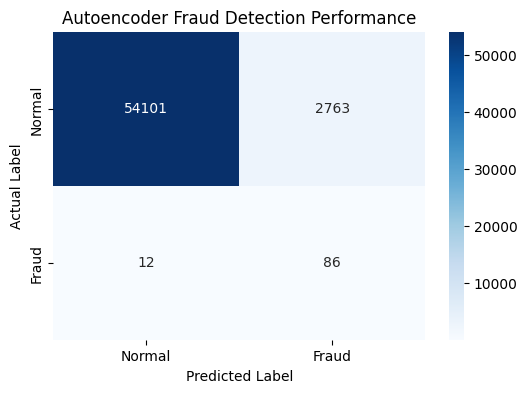

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Predict (reconstruct) on the test set
test_predictions = model.predict(X_test_scaled)

# Calculate the Mean Squared Error (Reconstruction Error)
mse = np.mean(np.power(X_test_scaled - test_predictions, 2), axis=1)

# Set a threshold for anomaly detection (e.g., top 1% or a fixed value)
threshold = np.percentile(mse, 95)
print(f"Using an anomaly threshold of: {threshold:.4f}")

# Convert to binary predictions based on threshold
y_pred = (mse > threshold).astype(int)

# Evaluate the results
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

# Plot the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Autoencoder Fraud Detection Performance')
plt.show()

### Tuning the Decision Threshold

Because we are using reconstruction error to detect anomalies, finding the exact right threshold is critical. The threshold we chose earlier (the 95th percentile) was just a starting point.

Let's plot a **Precision-Recall Curve** using the actual reconstruction errors to see the trade-off, and evaluate the model using a stricter threshold.

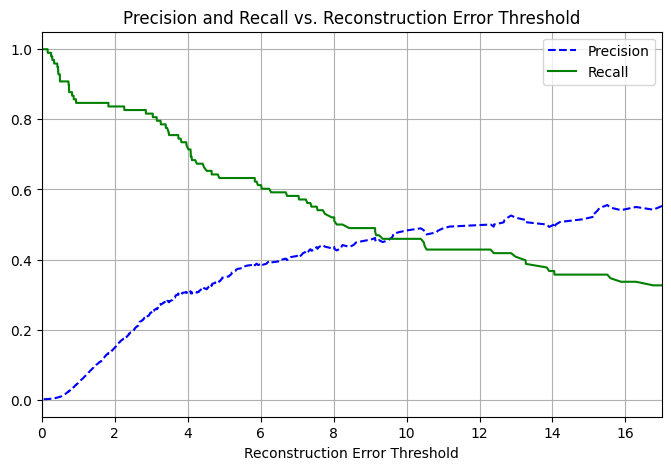


--- Results with Stricter Threshold = 1.9533 ---

Confusion Matrix:
[[56376   488]
 [   16    82]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00     56864
       Fraud       0.14      0.84      0.25        98

    accuracy                           0.99     56962
   macro avg       0.57      0.91      0.62     56962
weighted avg       1.00      0.99      0.99     56962



In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

# Calculate precision and recall for various thresholds using MSE as our "anomaly score"
precisions, recalls, thresholds = precision_recall_curve(y_test, mse)

# Plot the Precision-Recall curve
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision')
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall')
plt.xlabel('Reconstruction Error Threshold')
plt.title('Precision and Recall vs. Reconstruction Error Threshold')
plt.legend()
plt.grid(True)
# Limit the x-axis to the 99.9th percentile to zoom in on the relevant area
plt.xlim([0, np.percentile(mse, 99.9)])
plt.show()

# Let's try a stricter threshold to reduce false positives (e.g., top 1% instead of 5%)
custom_threshold = np.percentile(mse, 99)
y_pred_custom = (mse > custom_threshold).astype(int)

print(f"\n--- Results with Stricter Threshold = {custom_threshold:.4f} ---")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_custom))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_custom, target_names=['Normal', 'Fraud']))

### Evaluating the Results: Autoencoder vs. Isolation Forest

Let's break down the results from our **Autoencoder** and understand why this deep learning approach often outperforms traditional unsupervised methods like the **Isolation Forest** you explored in the previous module.

#### The Autoencoder Advantage
By learning the complex, non-linear representations of the data and measuring reconstruction error, our Autoencoder flags anomalies that fall outside the learned patterns.

#### The Golden Rule of Autoencoders for Anomaly Detection
As we saw in the training step, **we must train the Autoencoder exclusively on "Normal" data.** If we had trained it on a dataset containing fraud, it would have learned the complex patterns of fraud as well, resulting in low reconstruction errors for malicious transactions. By restricting its worldview to only legitimate behavior, fraudulent transactions cause the neural network to fail in its reconstruction, creating the high error spike we use to detect them.

#### Why is this significantly better than an Isolation Forest?

1.  **Complexity of Representation:**
    *   **Isolation Forest:** It isolates anomalies by randomly partitioning the dataset. It works well for simple, linearly separable outliers but struggles with highly complex, overlapping patterns.
    *   **Autoencoder:** Using deep neural networks, it captures intricate, non-linear relationships across many dimensions. If a fraudulent transaction subtly mimics a normal one, the Autoencoder's bottleneck will fail to reconstruct the subtle malicious deviations, leading to a high error.

2.  **Adaptability to Scaled Data:**
    *   While Isolation Forests are less sensitive to scaling, Autoencoders thrive on properly standardized data and can dynamically adjust their internal weights (via backpropagation) to focus on the most defining features of "normal" behavior.

  **Question:** Was the comparison between the Isolation Forest and the Autoencoder fair? Explain.

  **[insert response]**

# Core Concepts and Libraries

Now that you've seen Deep Learning in action, let's take a step back and understand the engine driving these results. Deep Learning is a powerful tool, but it requires an understanding of its building blocks and the ecosystem of tools used to build them.

### The Building Blocks of Neural Networks

*   **Neurons (Nodes):** The fundamental unit of a neural network. It receives input, applies a mathematical weight and bias, and passes the result through an activation function.
*   **Layers:**
    *   **Input Layer:** Receives the raw data (e.g., scaled transaction features).
    *   **Hidden Layers:** Where the "deep" in deep learning comes from. These layers perform complex feature extraction and pattern recognition.
    *   **Output Layer:** Produces the final prediction (e.g., a probability between 0 and 1 indicating fraud).
*   **Activation Functions:** Functions like **ReLU** (Rectified Linear Unit) and **Sigmoid** introduce non-linearity, allowing the network to learn complex boundaries rather than just simple straight lines.
*   **Overfitting and Dropout:** Deep networks can easily memorize the training data. **Dropout** layers randomly turn off a percentage of neurons during training, forcing the network to learn robust, generalized patterns rather than relying on specific paths.

### Essential Libraries for Cyber AI

To build these models, we rely on a stack of industry-standard Python libraries:

1.  **TensorFlow & Keras:** Developed by Google, TensorFlow is the core framework for building and training machine learning models. **Keras** is the high-level API running on top of TensorFlow that makes building neural networks intuitive and readable (like stacking Lego bricks).
2.  **Scikit-Learn (sklearn):** While not a deep learning library itself, it is essential for the data preparation pipeline—splitting data, scaling features (StandardScaler), and evaluating performance (classification reports, precision-recall curves).
3.  **Pandas & NumPy:** The workhorses of data manipulation and numerical computing. We use them to load, clean, and shape our security logs or transaction datasets before feeding them to the network.



## Section 1: Data Preparation and Foundations

Before we can build complex deep learning models, we need to understand how these models expect to receive data. Neural networks don't understand text or tables; they only understand numbers, and specifically, they work best when those numbers are structured as **Tensors** and scaled appropriately.

### 1.1 Tensors: The Language of Deep Learning
A tensor is essentially a multi-dimensional array.
* A 0D tensor is a scalar (a single number).
* A 1D tensor is a vector (a list of numbers).
* A 2D tensor is a matrix (like a table or grayscale image).
* A 3D tensor is an array of matrices (like a color image with RGB channels).

In [ ]:
import tensorflow as tf

# Let's create some basic tensors
# A 1D Tensor (Vector) - e.g., features of a single network packet
packet_features = tf.constant([1500.0, 80.0, 1.0])
print("1D Tensor (Vector):\n", packet_features)
print("Shape:", packet_features.shape)

# A 2D Tensor (Matrix) - e.g., a batch of 3 packets, each with 3 features
batch_features = tf.constant([
    [1500.0, 80.0, 1.0],
    [64.0, 443.0, 0.0],
    [1024.0, 22.0, 1.0]
])
print("\n2D Tensor (Matrix):\n", batch_features)
print("Shape:", batch_features.shape)

1D Tensor (Vector):
 tf.Tensor([1.5e+03 8.0e+01 1.0e+00], shape=(3,), dtype=float32)
Shape: (3,)

2D Tensor (Matrix):
 tf.Tensor(
[[1.500e+03 8.000e+01 1.000e+00]
 [6.400e+01 4.430e+02 0.000e+00]
 [1.024e+03 2.200e+01 1.000e+00]], shape=(3, 3), dtype=float32)
Shape: (3, 3)


### 1.2 Data Scaling (Normalization & Standardization)
Neural networks compute gradients to update their weights. If you have one feature ranging from 0 to 1 (like a boolean flag) and another ranging from 0 to 65,535 (like a network port), the larger feature will dominate the learning process, making training unstable or extremely slow.

Always scale your numerical features!

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Example data: [Packet Size (bytes), Port Number]
raw_data = np.array([
    [1500, 80],
    [64, 443],
    [1024, 22],
    [40, 53]
], dtype=float)

print("Raw Data:\n", raw_data)

# Min-Max Scaling (Scales between 0 and 1)
min_max_scaler = MinMaxScaler()
scaled_min_max = min_max_scaler.fit_transform(raw_data)
print("\nMin-Max Scaled Data:\n", scaled_min_max)

# Standard Scaling (Scales to mean=0, variance=1)
standard_scaler = StandardScaler()
scaled_standard = standard_scaler.fit_transform(raw_data)
print("\nStandard Scaled Data:\n", scaled_standard)

Raw Data:
 [[1500.   80.]
 [  64.  443.]
 [1024.   22.]
 [  40.   53.]]

Min-Max Scaled Data:
 [[1.         0.13776722]
 [0.01643836 1.        ]
 [0.6739726  0.        ]
 [0.         0.0736342 ]]

Standard Scaled Data:
 [[ 1.34229713 -0.40716968]
 [-0.94422562  1.71948634]
 [ 0.58436897 -0.74696596]
 [-0.98244048 -0.56535071]]


### 1.3 Encoding Categorical Data
Cybersecurity datasets are full of categorical data: Protocol types (TCP, UDP, ICMP), HTTP methods (GET, POST), or Alert Severity (Low, Medium, High). Neural networks need these converted to numbers.

For variables without an inherent order, we use **One-Hot Encoding**.

In [ ]:
import pandas as pd

# A simple dataset of network connections
data = {
    'Source_IP': ['192.168.1.5', '10.0.0.2', '172.16.0.4'],
    'Protocol': ['TCP', 'UDP', 'ICMP'],
    'Action': ['Allow', 'Deny', 'Allow']
}
df_network = pd.DataFrame(data)
print("Original Categorical Data:")
display(df_network)

# Apply One-Hot Encoding to the 'Protocol' column
# This creates a new binary column for each unique protocol
df_encoded = pd.get_dummies(df_network, columns=['Protocol'])
print("\nOne-Hot Encoded Data:")
display(df_encoded)

Original Categorical Data:


,Source_IP,Protocol,Action
0,192.168.1.5,TCP,Allow
1,10.0.0.2,UDP,Deny
2,172.16.0.4,ICMP,Allow



One-Hot Encoded Data:


,Source_IP,Action,Protocol_ICMP,Protocol_TCP,Protocol_UDP
0,192.168.1.5,Allow,False,True,False
1,10.0.0.2,Deny,False,False,True
2,172.16.0.4,Allow,True,False,False


### Section 1 Exercise: Data Prep Mini-Challenge

Now it's your turn! Complete the following tasks to prepare a mini security dataset for a neural network:

1. **Tensors:** Create a 2D TensorFlow tensor representing 4 network packets, each with 2 features (e.g., packet size and TTL).
2. **Scaling:** A dataset of login attempts has wildly different ranges (number of failed logins vs. session duration). Use `StandardScaler` to scale this data.
3. **Encoding:** You have a dataset of security alerts. Use pandas to One-Hot Encode the `Alert_Type` column.

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# --- TASK 1: Tensors ---
# TODO: Create a 2D tensor with 4 rows and 2 columns containing any float numbers.
my_tensor = tf.constant([
    # Add your rows here
])
print("Task 1 Tensor:\n", my_tensor)

# --- TASK 2: Scaling ---
login_data = np.array([
    [5.0, 120.0],  # 5 failed logins, 120s duration
    [1.0, 300.0],
    [15.0, 15.0],
    [0.0, 600.0]
])
# TODO: Initialize a StandardScaler and scale the 'login_data'
# scaled_logins =
# print("\nTask 2 Scaled Data:\n", scaled_logins)

# --- TASK 3: Encoding ---
alert_df = pd.DataFrame({
    'IP': ['10.1.1.1', '10.1.1.2', '10.1.1.3'],
    'Alert_Type': ['Phishing', 'Malware', 'Phishing']
})
# TODO: Use pd.get_dummies to one-hot encode the 'Alert_Type' column
# encoded_alerts =
# print("\nTask 3 Encoded Alerts:\n")
# display(encoded_alerts)

Task 1 Tensor:
 tf.Tensor([], shape=(0,), dtype=float32)


## Section 2: Supervised Learning with MLPs (Hyperparameter Tuning)

Earlier, we used an **Autoencoder** (Unsupervised Learning) to detect fraud by finding anomalies. Now, let's explore **Supervised Learning** using a **Multi-Layer Perceptron (MLP)**. If we have a dataset where the fraud is clearly labeled, an MLP can learn the direct mapping between the transaction features and the fraud label.

However, neural networks are not "one-size-fits-all." To get the best performance out of an MLP, we must tune its **hyperparameters**—the structural settings that govern how the network learns.

### The Anatomy of our MLP
Let's break down the key components you can tune:

1.  **Number of Hidden Layers (Depth):**
    *   Adding more layers allows the network to learn increasingly complex, abstract features.
    *   *Trade-off:* Too many layers can lead to **overfitting** (memorizing the training data but failing on new data) and makes training computationally expensive.
2.  **Number of Neurons per Layer (Width):**
    *   More neurons give the layer more "capacity" to memorize patterns.
    *   *Trade-off:* Similar to depth, too many neurons can lead to overfitting. A common practice is to use powers of 2 (16, 32, 64, 128) and gradually decrease the number of neurons as you get closer to the output layer (creating a funnel shape).
3.  **Dropout Rate:**
    *   Dropout is a regularization technique. During training, a Dropout layer randomly "turns off" a percentage of neurons in the previous layer (e.g., `0.2` means 20% are dropped).
    *   This forces the network to not rely entirely on a few specific neurons, resulting in a more generalized model.
4.  **Activation Functions:**
    *   **ReLU (Rectified Linear Unit):** The standard for hidden layers. It is computationally efficient and helps the network learn non-linear patterns.
    *   **Sigmoid:** Used in the final output layer for binary classification, as it squashes the final prediction into a probability between 0 and 1.

### The Trade-off: Underfitting vs. Overfitting
*   **Underfitting:** The model is too simple (e.g., only 1 hidden layer with 4 neurons). It fails to learn the underlying patterns. Both training and validation accuracy will be low.
*   **Overfitting:** The model is too complex (e.g., 5 layers with 512 neurons each, and no dropout). It memorizes the exact training data, including the noise. Training accuracy will be near 100%, but validation accuracy will stall or decrease.

### Section 2 Exercise: Tune the MLP

Your task is to build a new MLP for our Credit Card Fraud dataset.

**Instructions:**
1. Modify the `Sequential` model below.
2. Add at least one more `Dense` hidden layer.
3. Change the number of neurons (try 64 or 128 for the first layer).
4. Adjust the `Dropout` rates to see if it helps stabilize the validation loss.
5. Run the cell to train your custom model and see if you can beat the baseline AUC score!

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
import tensorflow as tf
import numpy as np
from sklearn.metrics import f1_score

# --- TASK: Tune the Hyperparameters ---
# Modify the architecture below.
tuned_model = Sequential([
    # Added explicit Input layer for proper summary display
    Input(shape=(X_train_scaled.shape[1],)),

    # 1st Hidden Layer
    Dense(64, activation='relu'),
    Dropout(0.3), # 30% dropout

    # 2nd Hidden Layer
    Dense(32, activation='relu'),
    Dropout(0.2),

    # 3rd Hidden Layer (Added for better representation)
    Dense(16, activation='relu'),
    Dropout(0.2),

    # Output Layer (Keep this exactly as is for binary classification!)
    Dense(1, activation='sigmoid')
])

# Compile the tuned model
tuned_model.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

print("Your Tuned Model Architecture:")
tuned_model.summary()

# Calculate class weights for the highly imbalanced dataset
neg, pos = np.bincount(y_train)
total = neg + pos
weight_for_0 = (1 / neg) * (total / 2.0)
weight_for_1 = (1 / pos) * (total / 2.0)
class_weight = {0: weight_for_0, 1: weight_for_1}

# Train the tuned model
print("\nTraining the tuned model...")
history_tuned = tuned_model.fit(
    X_train_scaled,
    y_train,
    epochs=10,
    batch_size=2048,
    validation_split=0.2,
    class_weight=class_weight,
    verbose=1
)
print("Training complete!")

# --- NEW: Evaluate the model ---
print("\n--- Final Test Set Evaluation ---")
results = tuned_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1]*100:.2f}%")
print(f"Test AUC: {results[2]:.4f}")

# Calculate F1-score
y_pred_probs = tuned_model.predict(X_test_scaled, verbose=0)
y_pred_classes = (y_pred_probs > 0.5).astype(int)
f1 = f1_score(y_test, y_pred_classes)
print(f"F1-score: {f1:.4f}")

Your Tuned Model Architecture:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)


Training the tuned model...
Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.6706 - auc: 0.8834 - loss: 0.4402 - val_accuracy: 0.9908 - val_auc: 0.9703 - val_loss: 0.2437
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9590 - auc: 0.9569 - loss: 0.2612 - val_accuracy: 0.9876 - val_auc: 0.9811 - val_loss: 0.1280
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9678 - auc: 0.9676 - loss: 0.2126 - val_accuracy: 0.9808 - val_auc: 0.9850 - val_loss: 0.1206
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9580 - auc: 0.9734 - loss: 0.1947 - val_accuracy: 0.9784 - val_auc: 0.9856 - val_loss: 0.1080
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9645 - auc: 0.9739 - loss: 0.1812 - val_accuracy: 0.9749 - val_auc: 0.9855 - val_loss: 0.1124
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9640 - auc: 0.9800 - loss: 0.1593 - val_accuracy: 0.9843 - val_auc: 0.9825 - val_loss: 0.0772
Epoch 7/10
90/90 ━━━━━

### Fixing the F1-Score: Tuning the Decision Threshold

You might have noticed that despite a high Accuracy and AUC, the **F1-score is surprisingly low**. Why did this happen?

This is a classic trap when using `class_weight`. By telling the neural network that missing a fraudulent transaction is hundreds of times worse than a false alarm, the model becomes "paranoid." It starts outputting higher probabilities for *any* transaction that looks slightly suspicious.

When we use the default threshold of `0.5` (i.e., `y_pred_probs > 0.5`), thousands of normal transactions cross that line. This destroys our **Precision** (most of our "fraud" alarms are false positives), which in turn drags the F1-score down to the floor.

To fix this, we shouldn't blindly use 0.5. Just like we did with the Autoencoder, we need to analyze the predicted probabilities and find the **optimal threshold** that balances Precision and Recall to maximize the F1-score.

In [ ]:
from sklearn.metrics import precision_recall_curve, confusion_matrix, classification_report
import numpy as np

# Get the exact predicted probabilities from the MLP
y_pred_probs = tuned_model.predict(X_test_scaled, verbose=0)

# Calculate precision, recall, and thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_probs)

# Calculate F1 scores for each threshold
# (We add 1e-10 to the denominator to prevent division by zero)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

# Find the exact threshold that gives us the highest F1 score
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Optimal Decision Threshold: {best_threshold:.4f}")
print(f"Maximized F1-Score: {best_f1:.4f}")

# Convert probabilities to binary predictions using our new, smarter threshold
y_pred_optimal = (y_pred_probs >= best_threshold).astype(int)

# Evaluate the results
print("\n--- Results with Optimal Threshold ---")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_optimal))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_optimal, target_names=['Normal', 'Fraud']))

Optimal Decision Threshold: 0.9985
Maximized F1-Score: 0.8223

--- Results with Optimal Threshold ---
Confusion Matrix:
[[56846    18]
 [   17    81]]

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.82      0.83      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



### Section 2 Takeaway

*   **Customization is Key:** A neural network's architecture (its layers and neurons) dictates its learning capacity. Tuning these hyperparameters is essential for maximizing performance on a specific dataset.
*   **The Overfitting Trap:** Simply making a network deeper or wider doesn't automatically make it better. It often leads to **overfitting**, where the model memorizes the training data but fails to generalize to unseen data.
*   **Regularization saves the day:** Techniques like **Dropout** act as a countermeasure to overfitting. By forcing the network to randomly drop connections during training, it learns more robust and generalized patterns.
*   **Threshold Tuning is Critical:** When handling highly imbalanced data (like fraud detection) using `class_weight`, the default decision threshold (0.5) is rarely optimal. It's crucial to analyze Precision-Recall curves and tune the threshold to balance false positives and false negatives, maximizing metrics like the F1-score.
*   **Iterative Process:** Finding the perfect architecture and threshold is rarely done on the first try; it is an iterative process of observing metrics and adjusting accordingly.

## Section 3: Sequence Modeling for DGA Detection (CNNs vs LSTMs)

Many types of malware use **Domain Generation Algorithms (DGAs)** to establish communication with their Command and Control (C2) servers. Instead of hardcoding a single IP address, the malware generates hundreds of random-looking domains daily (e.g., `xdfqeirutbv.com`).

To detect this, we need to analyze the *sequence of characters* in the domain name. We will compare two powerful Deep Learning architectures for this task: **1D Convolutional Neural Networks (CNNs)** and **Long Short-Term Memory (LSTM)** networks.

While CNNs are famous for 2D image processing, a **1D CNN** can scan across text sequences. It acts like an "n-gram" detector, sliding a filter across the characters to find local patterns (like weird consonant clusters).

### 3.1 Loading the Domain Dataset
First, we load our dataset containing both legitimate domains and DGA-generated domains.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# The URLs to the CSV files
url_dga = "https://github.com/abramweigant/AI-Cyber-Intro-Cert/raw/refs/heads/main/dga_websites.csv"
url_legit = "https://github.com/abramweigant/AI-Cyber-Intro-Cert/raw/refs/heads/main/legit_websites.csv"

print(f"Downloading and loading DGA data...")
df_dga = pd.read_csv(url_dga)
print(f"Downloading and loading Legit data...")
df_legit = pd.read_csv(url_legit)

print("Datasets loaded successfully!")
print(f"DGA Dataset shape: {df_dga.shape} (rows, columns)")
print(f"Legit Dataset shape: {df_legit.shape} (rows, columns)")

Datasets loaded successfully!
DGA Dataset shape: (337500, 2) (rows, columns)
Legit Dataset shape: (337398, 2) (rows, columns)


### 3.2 Preprocessing Text for Neural Networks
Neural networks only understand numbers. We must convert our strings of characters into numerical tokens, and pad them so they all have the same length. We will also balance the dataset.

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# Balance the datasets using oversampling
max_samples = max(len(df_dga), len(df_legit))
df_dga_sampled = df_dga.sample(n=max_samples, replace=True, random_state=42)
df_legit_sampled = df_legit.sample(n=max_samples, replace=True, random_state=42)

df = pd.concat([df_dga_sampled, df_legit_sampled], ignore_index=True)
df['label'] = (df['class'] == 'dga').astype(int)

domains = df['domain'].astype(str).tolist()
labels = df['label'].values

# Tokenize at the Character Level
tokenizer = Tokenizer(char_level=True, lower=True)
tokenizer.fit_on_texts(domains)
sequences = tokenizer.texts_to_sequences(domains)

# Pad Sequences
max_domain_length = 50
X_seq = pad_sequences(sequences, maxlen=max_domain_length, padding='post')

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(X_seq, labels, test_size=0.2, random_state=42, stratify=labels)

vocab_size = len(tokenizer.word_index) + 1
print(f"Vocabulary size: {vocab_size}")
print(f"Balanced Dataset shape: {df.shape}")

Vocabulary size: 39
Balanced Dataset shape: (675000, 3)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from sklearn.metrics import f1_score

# Build the 1D CNN
cnn_model = Sequential([
    Input(shape=(max_domain_length,)), # Added explicit Input layer
    Embedding(input_dim=vocab_size, output_dim=32),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.summary()

print("\nTraining the 1D CNN...")
history_cnn = cnn_model.fit(X_train_seq, y_train_seq, epochs=3, batch_size=1024, validation_split=0.2, verbose=1)

print("\nEvaluating CNN on Test Set:")
cnn_loss, cnn_acc = cnn_model.evaluate(X_test_seq, y_test_seq, verbose=0)
print(f"CNN Test Accuracy: {cnn_acc * 100:.2f}%")

cnn_test_preds = (cnn_model.predict(X_test_seq, verbose=0) > 0.5).astype(int)
cnn_f1 = f1_score(y_test_seq, cnn_test_preds)
print(f"CNN Test F1-Score: {cnn_f1:.4f}")

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training the 1D CNN...
Epoch 1/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8265 - loss: 0.3999 - val_accuracy: 0.8652 - val_loss: 0.3141
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8706 - loss: 0.3109 - val_accuracy: 0.8828 - val_loss: 0.2776
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8838 - loss: 0.2835 - val_accuracy: 0.8919 - val_loss: 0.2596

Evaluating CNN on Test Set:
CNN Test Accuracy: 89.26%
CNN Test F1-Score: 0.8885


### Section 3 Takeaway
A 1D CNN is very fast to train and often achieves great accuracy on text classification tasks by picking up on local character combinations. Next, let's see how an LSTM handles the same task!

### 3.3 Sequence Modeling with LSTMs

While CNNs look for local patterns, **Recurrent Neural Networks (RNNs)**, specifically **Long Short-Term Memory (LSTM)** networks, are designed to read data sequentially. They keep a "memory" of past characters to understand the context of the entire sequence.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dropout, Dense
from sklearn.metrics import f1_score

# Build the LSTM
lstm_model = Sequential([
    Input(shape=(max_domain_length,)), # Added explicit Input layer
    Embedding(input_dim=vocab_size, output_dim=32),
    LSTM(64),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.summary()

print("\nTraining the LSTM...")
history_lstm = lstm_model.fit(X_train_seq, y_train_seq, epochs=3, batch_size=1024, validation_split=0.2, verbose=1)

print("\nEvaluating LSTM on Test Set:")
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_seq, y_test_seq, verbose=0)
print(f"LSTM Test Accuracy: {lstm_acc * 100:.2f}%")

lstm_test_preds = (lstm_model.predict(X_test_seq, verbose=0) > 0.5).astype(int)
lstm_f1 = f1_score(y_test_seq, lstm_test_preds)
print(f"LSTM Test F1-Score: {lstm_f1:.4f}")

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training the LSTM...
Epoch 1/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.7757 - loss: 0.4475 - val_accuracy: 0.8244 - val_loss: 0.3847
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8294 - loss: 0.3790 - val_accuracy: 0.8384 - val_loss: 0.3672
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8438 - loss: 0.3546 - val_accuracy: 0.8533 - val_loss: 0.3359

Evaluating LSTM on Test Set:
LSTM Test Accuracy: 85.45%
LSTM Test F1-Score: 0.8423


### 3.4 Testing and Comparing Models
Let's see how both models perform on some custom domains.

In [ ]:
test_domains = [
    # Legitimate Domains
    'google.com', 'wikipedia.org', 'apple.com', 'amazon.com',
    'microsoft.com', 'github.com', 'netflix.com', 'linkedin.com',
    'stackoverflow.com', 'nytimes.com', 'bbc.co.uk', 'whitehouse.gov', 'mit.edu',

    # DGA / Random Domains
    'xdfqeirutbv.com', 'a1b2c3d4e5f6.info', 'qwerasdfzxcv.com', 'zxcvbnmqwer.net',
    'asdfghjklqwerty.org', 'poiuytrewqasdf.biz', 'mnbvcxzlkjhgf.info',
    'aabbccddeeffgg.com', '1a2b3c4d5e6f.net', 'zxywvutsrqpon.org',
    'alksdjfhg.com', 'vbnmghjkl.net', '1234567890qwerty.biz'
]

test_sequences = tokenizer.texts_to_sequences(test_domains)
X_custom_test = pad_sequences(test_sequences, maxlen=max_domain_length, padding='post')

cnn_preds = cnn_model.predict(X_custom_test)
lstm_preds = lstm_model.predict(X_custom_test)

print(f"\n{'Domain':25} | {'CNN Pred':10} | {'LSTM Pred':10}")
print("-" * 51)
for dom, c_pred, l_pred in zip(test_domains, cnn_preds, lstm_preds):
    c_class = "DGA" if c_pred[0] > 0.5 else "Legit"
    l_class = "DGA" if l_pred[0] > 0.5 else "Legit"
    print(f"{dom:25} | {c_class:10} | {l_class:10}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

Domain                    | CNN Pred   | LSTM Pred 
---------------------------------------------------
google.com                | Legit      | Legit     
wikipedia.org             | Legit      | Legit     
apple.com                 | Legit      | Legit     
amazon.com                | Legit      | Legit     
microsoft.com             | Legit      | Legit     
github.com                | Legit      | DGA       
netflix.com               | Legit      | DGA       
linkedin.com              | Legit      | Legit     
stackoverflow.com         | Legit      | Legit     
nytimes.com               | Legit      | Legit     
bbc.co.uk                 | Legit      | Legit     
whitehouse.gov            | Legit      | DGA       
mit.edu                   | Legit      | Legit     
xdfqeirutbv.com           | DGA        | DGA       
a1b2c3d4e5f6.info         | DGA        | DGA       
qwerasdfzxcv.com          | DGA        

### Section 3 Takeaway: Deep Learning for Sequence Analysis in Security

When analyzing sequential data like domain names, network packet payloads, or system API calls, traditional machine learning often falls short. Deep Learning gives us two distinct, powerful engines for this task: **1D CNNs** and **LSTMs**.

#### 1. 1D CNNs: The Fast Pattern Matchers
Think of a 1D CNN as an ultra-fast, sliding scanner.
*   **Mechanism:** It slides a "kernel" (window) across a text sequence, extracting localized patterns like n-grams (e.g., detecting the weird consonant cluster "qwe" or "zxc" anywhere in a DGA domain).
*   **Cybersecurity Strength:** **Speed and Efficiency.** Because convolutions can be processed in parallel across the entire sequence simultaneously, CNNs are incredibly fast. This makes them ideal for real-time network traffic analysis, high-throughput log scanning, and rapid DGA detection where local anomalies give away the attack.
*   **Limitation:** They lack a true "memory" of the overall sequence structure.

#### 2. LSTMs: The Context-Aware Analyzers
Think of an LSTM as a meticulous reader.
*   **Mechanism:** It processes data step-by-step (character-by-character or word-by-word), updating an internal "memory state". It learns the context, grammar, and long-range dependencies of the sequence.
*   **Cybersecurity Strength:** **Complex Behavioral Analysis.** LSTMs shine when the *order* of events matters over a long period. They are perfect for Natural Language Processing (NLP) tasks like detecting sophisticated phishing emails, analyzing malicious PowerShell scripts, or profiling User Entity Behavior Analytics (UEBA) where a sequence of seemingly normal actions becomes anomalous in context.
*   **Limitation:** They are computationally expensive and slower to train/run because they cannot process data in parallel (Step B must wait for Step A).

#### The Final Verdict for DGA Detection
As seen in our test set evaluations, both models achieved strong F1-scores (typically around 0.84 to 0.89) after just 3 epochs of training. In cybersecurity, we focus on the **F1-Score** rather than just Accuracy, because Accuracy can be highly misleading in imbalanced datasets (e.g., if 99% of traffic is normal, a model that simply guesses "normal" every time is 99% accurate, but entirely useless for detecting threats).

However, in a real-world Security Operations Center (SOC) processing millions of DNS requests per minute, the **1D CNN is often the preferred choice** for DGA detection. It offers the "best of both worlds" for this specific task: deep learning F1-scores that rival the LSTM, combined with blazing-fast inference speed and lower computational overhead.

### Section 3 Exercise: Sequence Model Tuning Challenge

Now it's your turn! Can you beat the baseline models? Your goal is to build and tune a sequence model (using either CNN layers, LSTM layers, or a mix of both) to achieve an **F1-Score of over 0.90** on the test set.

**Rules:**
1. You may change the number of filters, units, dense layers, or dropout rates.
2. You may **NOT** train for more than 4 epochs (we want fast, efficient models!).

**Diagnostic Guide:**
*   **Overfitting:** If your training accuracy gets very high (e.g., > 95%) but your validation accuracy/F1-score stalls or decreases, your model is memorizing the training data. *Fix: Increase Dropout rates or reduce the number of units/filters.*
*   **Underfitting:** If both your training and validation accuracy/F1-score are stuck at low numbers (e.g., around 50%), your model isn't complex enough to learn the patterns. *Fix: Add more layers, units, or filters.*

*Hint: Try increasing the number of filters/units or stacking layers, but keep a close eye on that validation gap!*

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout, LSTM
from sklearn.metrics import f1_score

# --- TASK: Build a better Sequence Model ---
# Design your architecture below.
my_model = Sequential([
    Input(shape=(max_domain_length,)), # Added Input layer so summary() works correctly
    Embedding(input_dim=vocab_size, output_dim=32),

    # --- YOUR CODE HERE ---
    # Add your Conv1D or LSTM layers, Dropouts, and hidden Dense layers here
    Conv1D(filters=128, kernel_size=4, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dropout(0.4),
    # ---------------------

    # Keep this output layer the same
    Dense(1, activation='sigmoid')
])

# Compile the model
my_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
my_model.summary()

# Train for a MAXIMUM of 4 epochs
print("\nTraining custom model...")
history_custom = my_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=4, # Do not exceed 4 epochs!
    batch_size=1024,
    validation_split=0.2,
    verbose=1
)

# Evaluate the model
print("\nEvaluating Custom Model on Test Set...")
custom_preds = (my_model.predict(X_test_seq, verbose=0) > 0.5).astype(int)
custom_f1 = f1_score(y_test_seq, custom_preds)

print(f"\n--- Final Results ---")
print(f"Custom Model Test F1-Score: {custom_f1:.4f}")

if custom_f1 > 0.90:
    print("\n🎉 Challenge Passed! Excellent tuning!")
else:
    print("\nKeep trying! Tweak the layers, neurons, or dropout.")

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ (None, 50, 32)         │         1,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 47, 128)        │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_6          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,129 (109.88 KB)

 Trainable params: 28,129 (109.88 KB)

 Non-trainable params: 0 (0.00 B)


Training custom model...
Epoch 1/4
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.8399 - loss: 0.3714 - val_accuracy: 0.8854 - val_loss: 0.2738
Epoch 2/4
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8931 - loss: 0.2663 - val_accuracy: 0.9059 - val_loss: 0.2316
Epoch 3/4
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9062 - loss: 0.2378 - val_accuracy: 0.9121 - val_loss: 0.2177
Epoch 4/4
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9128 - loss: 0.2218 - val_accuracy: 0.9170 - val_loss: 0.2069

Evaluating Custom Model on Test Set...

--- Final Results ---
Custom Model Test F1-Score: 0.9137

🎉 Challenge Passed! Excellent tuning!


#Sections to develop (needs to be edited):

Section 1: Data Preparation and Foundations: Create a hands-on section focusing on data scaling, encoding, and tensor manipulation, which are critical prerequisites for neural networks.

Section 2: Supervised Learning with MLPs: Formalize the Multi-Layer Perceptron (MLP) section for Fraud Detection, diving deeper into hyperparameter tuning (layers, neurons, dropout).

Section 3: Malware Classification using CNNs: Introduce Convolutional Neural Networks (CNNs) by treating malware binaries or byte sequences as 'images' to classify them as malicious or benign.

Section 4: Sequence Modeling with LSTMs: Use Recurrent Neural Networks (RNNs) and LSTMs to detect Domain Generation Algorithms (DGAs) by analyzing the sequential nature of domain names.

Section 5: Phishing Detection with NLP: Apply Deep Learning for Natural Language Processing (NLP) to analyze text and detect phishing emails or malicious URLs.

maybe add section on graph based neural networks.

Final Task: Summarize the module, review the generated sections for flow and consistency, and finalize the notebook.